In [4]:
import pickle
import functools

from notebooks.utils import (
    generate_layerwise_visualization_v3,
    plot_comparison_with_agreement,
    is_pair_interesting
)

In [5]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("xpmir/cross-encoder-bert-base-infoNCE")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 3072


<Figure size 640x480 with 0 Axes>

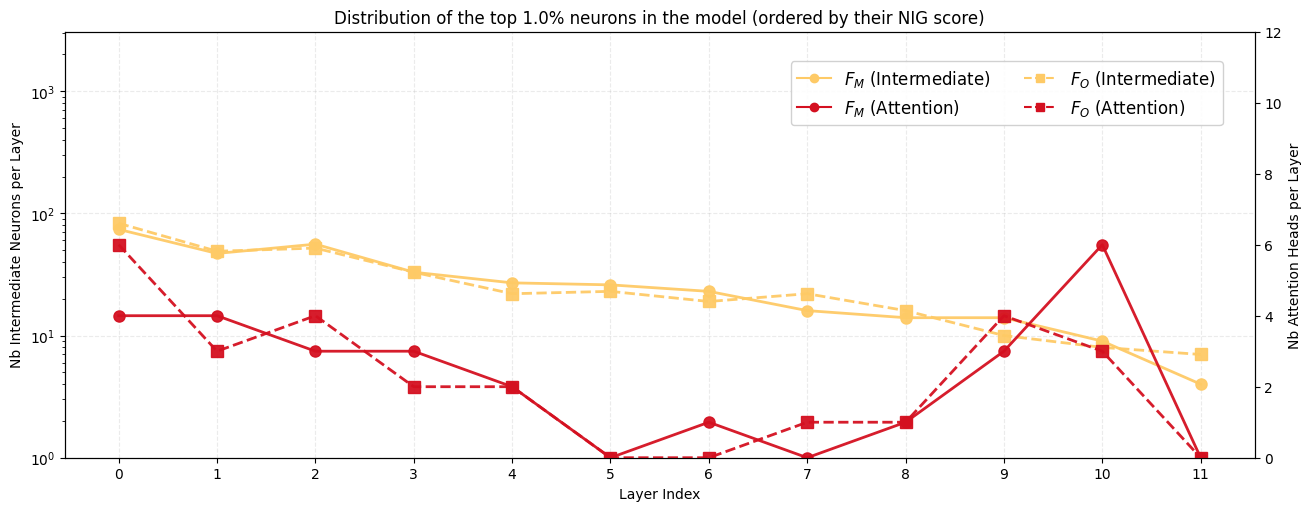

In [6]:
model = "monobert_base"
percentage = 0.01
names = ["msmarco_fusion", "OOD_fusion"]
paths = [
    f"/home/vast/target_dir/relevance-integrations/jobs/src.ablation.ablation_infonce.ablationschemes/ca750030a89b314bc5e7ea00f21b67ea9e284b6add24b1f4c2d77ac1f3536e5b/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

<Figure size 640x480 with 0 Axes>

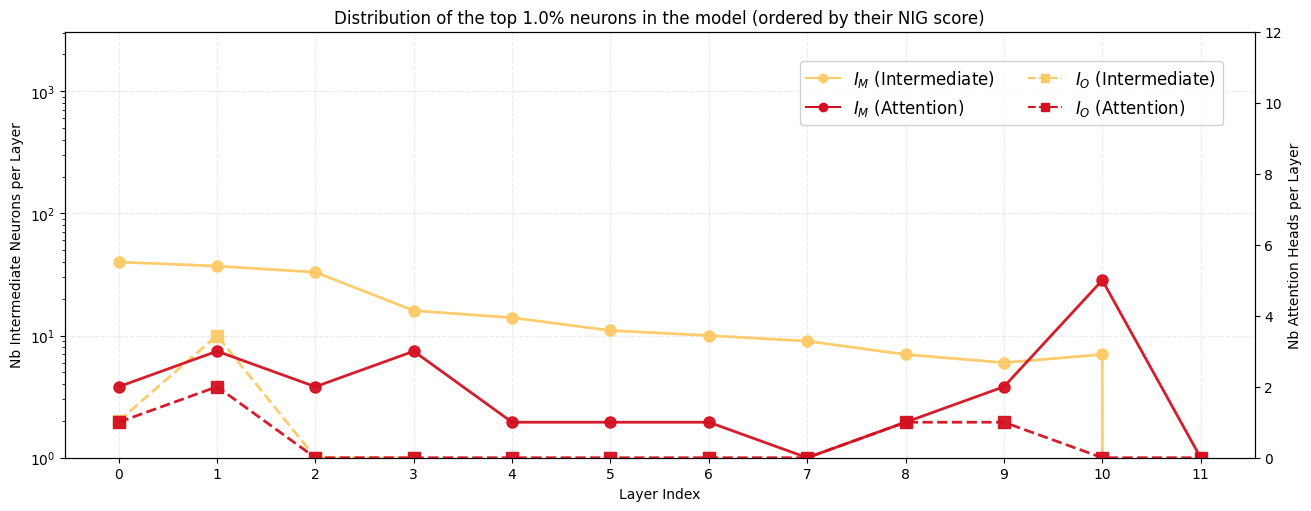

In [7]:
model = "monobert_base"
percentage = 0.01
names = ["msmarco_intersection", "OOD_intersection"]
paths = [
    f"/home/vast/target_dir/relevance-integrations/jobs/src.ablation.ablation_infonce.ablationschemes/ca750030a89b314bc5e7ea00f21b67ea9e284b6add24b1f4c2d77ac1f3536e5b/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

<Figure size 640x480 with 0 Axes>

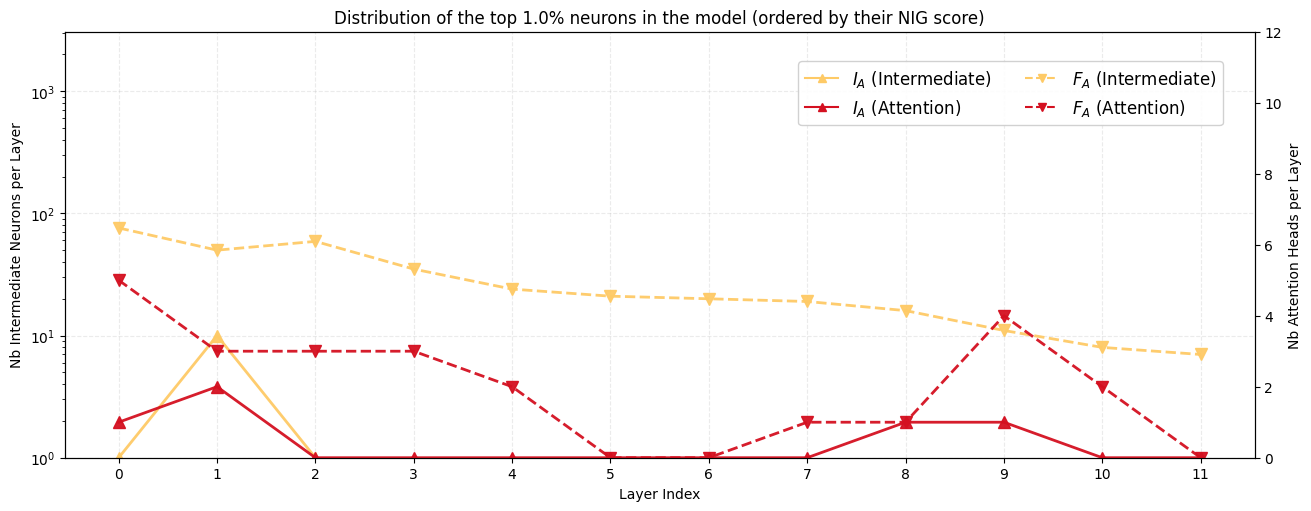

In [8]:
model = "monobert_base"
percentage = 0.01
names = ["ALL_intersection", "ALL_fusion"]
paths = [
    f"/home/vast/target_dir/relevance-integrations/jobs/src.ablation.ablation_infonce.ablationschemes/ca750030a89b314bc5e7ea00f21b67ea9e284b6add24b1f4c2d77ac1f3536e5b/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

/home/vast/CE-relevance-integration/src/notebooks/utils.py:616: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=100)


<Figure size 640x480 with 0 Axes>

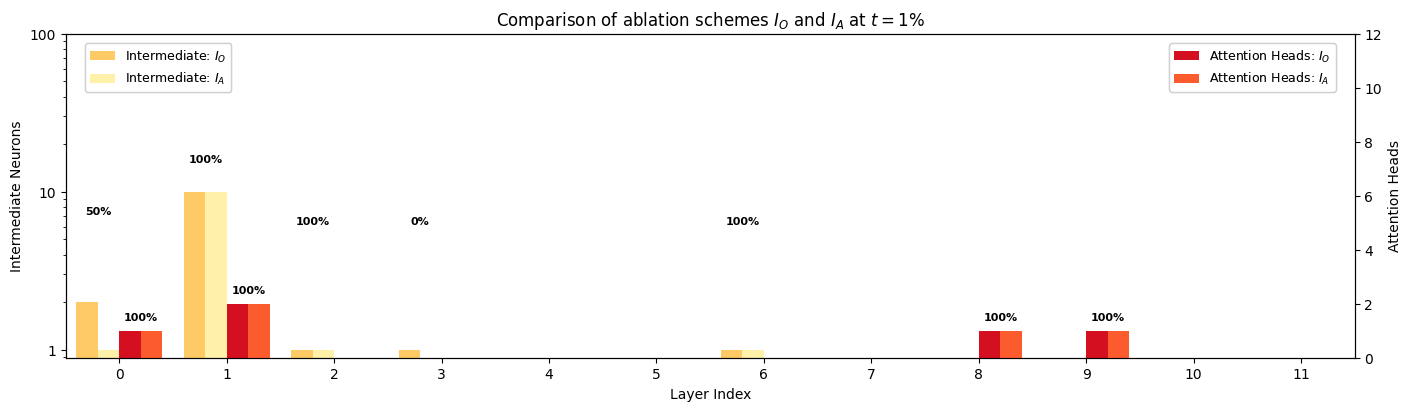

In [9]:
percentage = 0.01    
path1 = f"/home/vast/target_dir/relevance-integrations/jobs/src.ablation.ablation_infonce.ablationschemes/ca750030a89b314bc5e7ea00f21b67ea9e284b6add24b1f4c2d77ac1f3536e5b/ablation_schemes_at_percentage{percentage}_OOD_intersection.pkl"
path2 = f"/home/vast/target_dir/relevance-integrations/jobs/src.ablation.ablation_infonce.ablationschemes/ca750030a89b314bc5e7ea00f21b67ea9e284b6add24b1f4c2d77ac1f3536e5b/ablation_schemes_at_percentage{percentage}_ALL_intersection.pkl"
model_name = "monobert_base"

with open(path1, "rb") as f1, open(path2, "rb") as f2:
    raw1 = pickle.load(f1)
    raw2 = pickle.load(f2)

plot_comparison_with_agreement(
    raw1, raw2,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    model_name=model_name
)

In [10]:
target_modules_regex = ["attention_probs"]

nig_pkl_files = [
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/4e104315e852080b79134fa198d5dafb6b4da4d7a8bbc86916ae3bf29778ea22/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/61e3753abfc4a992abc8c689d702a822d52ac0af75483555124b1572127b9d60/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/eb7352251b2759af99a378207578fd443dc6da6094038256742845e7ab1d28b9/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/efea2289050ec80f15bdbf756e13f736d28b56cf7f631d8cbdb0dc067ec59b30/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/3b67da08818f071c2502d0cfd5f68ef9bde209508686a10663d6965f411e3d4f/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/5b48a3f9673c043e59eb791ea4f178799dcf569f08e7ad9c6ad95fac621deeb2/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/f78f4b2a4b3b78a3bb750a2b681b3bf20f22612d99531651bfb9269a8207aa0a/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/7af934acd00cb66cafed6298004fee45c3f64e93bcd93db5e770492e32cd6762/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/8cdce4d38b31e275827ec8d45df48cbf53a4c73d0853c38de12b556c4f641341/aggregation_result.pkl",
    "/home/vast/target_dir/relevance-integrations/jobs/src.xps.aggregation.aggregationresults/d89126d1a4d1d91953b478ef9ac14222dfb78b5c4600f7e0e081f1e4a2320ea0/aggregation_result.pkl"
]
target_fusion_dict = dict()
for idx, nig_pkl_file in enumerate(nig_pkl_files):
    with open(nig_pkl_file, 'rb') as f:
        nig_model = pickle.load(f)

    nig_model = dict(filter(functools.partial(is_pair_interesting, regex=target_modules_regex), nig_model.items()))

    attention_probs_keys = [key for key in nig_model.keys() if "attention_probs" in key]
    # As the attention_probs module is a 4D tensors with an additional dimensio for the attention_heads
    # we split it into attention_heads 3D tensors in order for it to match the shape of the others
    for key in attention_probs_keys:
        if "attention_probs" in key:
            attention_probs = nig_model.pop(key)
            for direction, values in attention_probs.items():
                for n, attention_head in enumerate(values):
                    if key + f'.{n}' in nig_model.keys():
                        nig_model[key + f'.{n}'][direction] = attention_head # Little trick to tranform every tensor to the same shape
                    else:
                        nig_model[key + f'.{n}'] = {direction: attention_head}

    if idx == 0:
        for module, values_per_input_type in nig_model.items():
            target_fusion_dict[module] = dict()
            for input_type, value in values_per_input_type.items():
                target_fusion_dict[module][input_type] = value

    else:
        for module, values_per_input_type in nig_model.items():
            for input_type, value in values_per_input_type.items():
                target_fusion_dict[module][input_type] += value

for module, value_per_input_type in target_fusion_dict.items():
    for input_type, value in value_per_input_type.items():
        target_fusion_dict[module][input_type] = value / len(nig_pkl_files)

sorted_target_fusion_dict = dict(
    sorted(
        target_fusion_dict.items(),
        key=lambda item: item[1]['all'],
        reverse=True
    )
)

print(sorted_target_fusion_dict.keys())
parsed_keys_dict = {
    f"{k.split('.')[3]}/{k.split('.')[-1]}": v
    for k, v in sorted_target_fusion_dict.items()
}
print(list(parsed_keys_dict.keys())[0:10])

dict_keys(['bert.encoder.layer.3.attention.self.attention_probs.0', 'bert.encoder.layer.1.attention.self.attention_probs.7', 'bert.encoder.layer.2.attention.self.attention_probs.6', 'bert.encoder.layer.0.attention.self.attention_probs.9', 'bert.encoder.layer.0.attention.self.attention_probs.10', 'bert.encoder.layer.1.attention.self.attention_probs.6', 'bert.encoder.layer.9.attention.self.attention_probs.5', 'bert.encoder.layer.10.attention.self.attention_probs.3', 'bert.encoder.layer.9.attention.self.attention_probs.11', 'bert.encoder.layer.0.attention.self.attention_probs.4', 'bert.encoder.layer.10.attention.self.attention_probs.7', 'bert.encoder.layer.8.attention.self.attention_probs.6', 'bert.encoder.layer.0.attention.self.attention_probs.1', 'bert.encoder.layer.4.attention.self.attention_probs.7', 'bert.encoder.layer.3.attention.self.attention_probs.3', 'bert.encoder.layer.9.attention.self.attention_probs.1', 'bert.encoder.layer.2.attention.self.attention_probs.2', 'bert.encoder.la